In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("dft-road-casualty-statistics-collision-last-5-years.csv", low_memory=False)
print("Shape:", df.shape)
df.head()

Shape: (503475, 44)


,collision_index,collision_year,collision_ref_no,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,collision_severity,number_of_vehicles,...,carriageway_hazards_historic,carriageway_hazards,urban_or_rural_area,did_police_officer_attend_scene_of_accident,trunk_road_flag,lsoa_of_accident_location,enhanced_severity_collision,collision_injury_based,collision_adjusted_severity_serious,collision_adjusted_severity_slight
0,2021170H10421,2021,170H10421,447098.0,532997.0,-1.270905,54.689833,17,3,2,...,0,0,2,1,2,E01011959,-1,0,0.293588,0.706412
1,2021170H11231,2021,170H11231,450486.0,533118.0,-1.218333,54.690592,17,3,2,...,0,0,1,2,2,E01011973,-1,0,0.017448,0.982552
2,2020170M11750,2020,170M11750,449694.0,519733.0,-1.232884,54.570397,17,3,2,...,0,0,1,1,2,E01012092,-1,0,0.128730,0.871270
3,2021170M31761,2021,170M31761,449744.0,514217.0,-1.233040,54.520825,17,3,1,...,0,0,2,1,2,E01032553,-1,0,0.182698,0.817302
4,2021170S10441,2021,170S10441,445971.0,520834.0,-1.290292,54.580641,17,3,3,...,0,13,2,1,1,E01012258,-1,0,0.016094,0.983906


In [ ]:
df = df[['collision_severity', 'date', 'time',
         'day_of_week', 'latitude', 'longitude',
         'speed_limit', 'road_type',
         'light_conditions', 'weather_conditions',
         'road_surface_conditions', 'urban_or_rural_area']]

df.head()

,collision_severity,date,time,day_of_week,latitude,longitude,speed_limit,road_type,light_conditions,weather_conditions,road_surface_conditions,urban_or_rural_area
0,3,22/05/2021,22:44,7,54.689833,-1.270905,60,6,6,1,1,2
1,3,20/10/2021,15:50,4,54.690592,-1.218333,30,6,1,1,1,1
2,3,01/12/2020,18:00,3,54.570397,-1.232884,20,6,4,1,1,1
3,3,09/12/2021,16:55,5,54.520825,-1.233040,40,6,4,1,2,2
4,3,12/04/2021,09:02,2,54.580641,-1.290292,70,3,1,1,1,2


In [ ]:
df = df.dropna(subset=['latitude', 'longitude'])
print(df.shape)

(503410, 12)


In [ ]:
df['date'] = pd.to_datetime(df['date'], dayfirst=True, errors='coerce')
df['hour'] = pd.to_datetime(df['time'], format='%H:%M', errors='coerce').dt.hour
df['day'] = df['date'].dt.day
df['month'] = df['date'].dt.month

Class Distribution (Counts):
collision_severity
Slight     385960
Serious    109960
Fatal        7490
Name: count, dtype: int64

Class Distribution (Percentage):
collision_severity
Slight     76.669117
Serious    21.843031
Fatal       1.487853
Name: proportion, dtype: float64


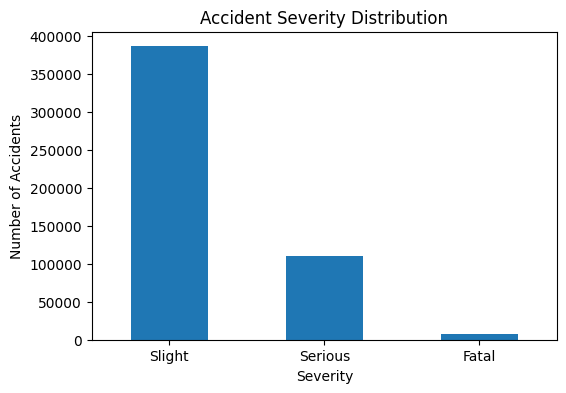

In [ ]:
severity_map = {
    1: "Fatal",
    2: "Serious",
    3: "Slight"
}

severity_labels = df['collision_severity'].map(severity_map)

print("Class Distribution (Counts):")
print(severity_labels.value_counts())

print("\nClass Distribution (Percentage):")
print(severity_labels.value_counts(normalize=True) * 100)


plt.figure(figsize=(6,4))

severity_labels.value_counts().plot(kind='bar')

plt.title("Accident Severity Distribution")
plt.xlabel("Severity")
plt.ylabel("Number of Accidents")

plt.xticks(rotation=0)
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

df_base = df.drop(columns=['date', 'time'])
X = df_base.drop(columns=['collision_severity'])
y = df_base['collision_severity']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

lr = LogisticRegression(max_iter=200, n_jobs=-1)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Logistic Regression\n")
print(classification_report(y_test, y_pred_lr, zero_division=0))

Logistic Regression

              precision    recall  f1-score   support

           1       0.00      0.00      0.00      1498
           2       0.00      0.00      0.00     21992
           3       0.77      1.00      0.87     77192

    accuracy                           0.77    100682
   macro avg       0.26      0.33      0.29    100682
weighted avg       0.59      0.77      0.67    100682



In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_base = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_base.fit(X_train, y_train)
y_pred_rf = rf_base.predict(X_test)

print("Random Forest (Imbalanced)\n")
print(classification_report(y_test, y_pred_rf, zero_division=0))

Random Forest (Imbalanced)

              precision    recall  f1-score   support

           1       0.23      0.00      0.00      1498
           2       0.38      0.04      0.08     21992
           3       0.77      0.98      0.86     77192

    accuracy                           0.76    100682
   macro avg       0.46      0.34      0.31    100682
weighted avg       0.68      0.76      0.68    100682



In [ ]:
from xgboost import XGBClassifier

y_train_xgb = y_train - 1
y_test_xgb = y_test - 1

xgb = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb.fit(X_train, y_train_xgb)
y_pred_xgb = xgb.predict(X_test)
y_pred_xgb = y_pred_xgb + 1

print("XGBoost\n")
print(classification_report(y_test, y_pred_xgb, zero_division=0))

XGBoost

              precision    recall  f1-score   support

           1       0.00      0.00      0.00      1498
           2       0.49      0.02      0.03     21992
           3       0.77      1.00      0.87     77192

    accuracy                           0.77    100682
   macro avg       0.42      0.34      0.30    100682
weighted avg       0.70      0.77      0.67    100682



In [ ]:
from sklearn.utils import resample

df_fatal = df_base[df_base['collision_severity'] == 1]
df_serious = df_base[df_base['collision_severity'] == 2]
df_slight = df_base[df_base['collision_severity'] == 3]

max_size = len(df_slight)

df_fatal_up = resample(df_fatal, replace=True, n_samples=max_size, random_state=42)
df_serious_up = resample(df_serious, replace=True, n_samples=max_size, random_state=42)

df_over_balanced = pd.concat([df_fatal_up, df_serious_up, df_slight])

In [ ]:
X_over_bal = df_over_balanced.drop(columns=['collision_severity'])
y_over_bal = df_over_balanced['collision_severity']

X_train_ob, X_test_ob, y_train_ob, y_test_ob = train_test_split(
    X_over_bal, y_over_bal,
    test_size=0.2,
    random_state=42,
    stratify=y_over_bal
)

In [ ]:
y_train_xgb = y_train_ob - 1
y_test_xgb = y_test_ob - 1

xgb_bal = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

xgb_bal.fit(X_train_ob, y_train_xgb)
y_pred_xgb_bal = xgb_bal.predict(X_test_ob)
y_pred_xgb_bal = y_pred_xgb_bal + 1

print("XGBoost + Oversampling\n")
print(classification_report(y_test_ob, y_pred_xgb_bal, zero_division=0))

XGBoost + Oversampling

              precision    recall  f1-score   support

           1       0.60      0.73      0.66     77192
           2       0.48      0.34      0.40     77192
           3       0.52      0.57      0.54     77192

    accuracy                           0.54    231576
   macro avg       0.53      0.54      0.53    231576
weighted avg       0.53      0.54      0.53    231576



In [ ]:
from sklearn.metrics import confusion_matrix

rf_ob = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=10,
    random_state=42,
    n_jobs=-1
)

rf_ob.fit(X_train_ob, y_train_ob)
y_pred_ob = rf_ob.predict(X_test_ob)

print("Final Model - Random Forest + Oversampling\n")
print(classification_report(y_test_ob, y_pred_ob, zero_division=0))
print(confusion_matrix(y_test_ob, y_pred_ob))

Final Model - Random Forest + Oversampling

              precision    recall  f1-score   support

           1       0.72      0.85      0.78     77192
           2       0.62      0.44      0.52     77192
           3       0.58      0.64      0.61     77192

    accuracy                           0.64    231576
   macro avg       0.64      0.64      0.63    231576
weighted avg       0.64      0.64      0.63    231576

[[65802  3890  7500]
 [15235 34171 27786]
 [10992 17128 49072]]


In [ ]:
rf_final_full = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=10,
    random_state=42,
    n_jobs=-1
)

X_full = df_over_balanced.drop(columns=['collision_severity'])
y_full = df_over_balanced['collision_severity']

rf_final_full.fit(X_full, y_full)

RandomForestClassifier(max_depth=15, min_samples_split=10, n_estimators=200,
                       n_jobs=-1, random_state=42)

In [ ]:
df_base['predicted_risk'] = rf_final_full.predict(
    df_base.drop(columns=['collision_severity'])
)

In [ ]:
df_base['lat_bin'] = df_base['latitude'].round(3)
df_base['lon_bin'] = df_base['longitude'].round(3)

In [ ]:
hotspot_df = df_base.groupby(['lat_bin', 'lon_bin']).agg(
    avg_risk=('predicted_risk', 'mean'),
    accident_count=('predicted_risk', 'count')
).reset_index()

hotspot_df['normalized_count'] = (
    hotspot_df['accident_count'] / hotspot_df['accident_count'].max()
)

hotspot_df['risk_score'] = (
    (4 - hotspot_df['avg_risk']) * hotspot_df['normalized_count']
)

hotspot_df = hotspot_df[hotspot_df['accident_count'] >= 5]

In [ ]:
threshold = hotspot_df['risk_score'].quantile(0.95)

hotspots = hotspot_df[hotspot_df['risk_score'] >= threshold]

In [ ]:
pd.set_option('display.width', 1000)
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)

In [ ]:
print("\n===== HOTSPOT COVERAGE =====")
print("Total locations:", len(hotspot_df))
print("Hotspots:", len(hotspots))

print("\n===== TOP 10 HIGH-RISK HOTSPOTS =====")
print(hotspots.sort_values(by='risk_score', ascending=False).head(10))

print("\n===== TOP 10 HIGH-FREQUENCY AREAS =====")
print(hotspot_df.sort_values(by='accident_count', ascending=False).head(10))

print("\n===== CORRELATION (Severity vs Frequency) =====")
print(hotspot_df[['avg_risk', 'accident_count']].corr())


===== HOTSPOT COVERAGE =====
Total locations: 13420
Hotspots: 698

===== TOP 10 HIGH-RISK HOTSPOTS =====
        lat_bin  lon_bin  avg_risk  accident_count  normalized_count  risk_score
179959   52.564   -1.503  1.000000              22          0.392857    1.178571
77206    51.461   -0.116  2.870370              54          0.964286    1.089286
69124    51.428   -0.168  2.982143              56          1.000000    1.017857
109750   51.584   -0.072  2.981818              55          0.982143    1.000000
106562   51.571   -0.096  2.980769              52          0.928571    0.946429
266441   53.815   -1.562  2.038462              26          0.464286    0.910714
65308    51.409   -0.122  2.958333              48          0.857143    0.892857
129120   51.750   -1.244  2.886364              44          0.785714    0.875000
257396   53.746   -2.488  2.080000              25          0.446429    0.857143
115567   51.613   -0.065  3.000000              47          0.839286    0.839286

==

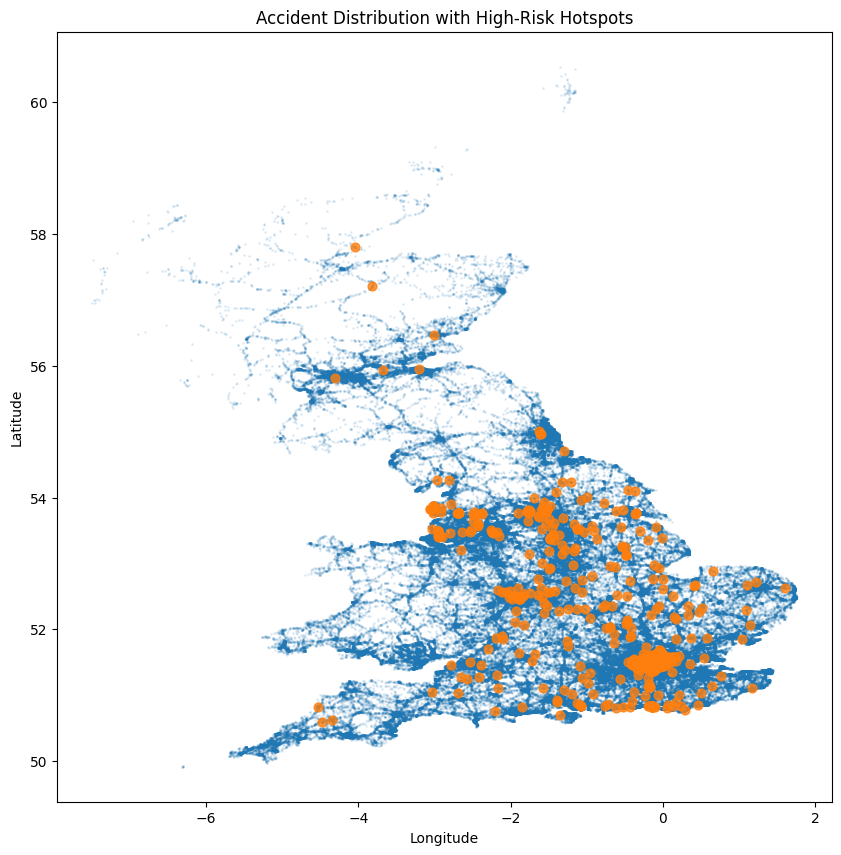

In [ ]:
plt.figure(figsize=(10, 10))

plt.scatter(
    df_base['longitude'],
    df_base['latitude'],
    s=1,
    alpha=0.1
)

plt.scatter(
    hotspots['lon_bin'],
    hotspots['lat_bin'],
    s=40,
    alpha=0.8
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Accident Distribution with High-Risk Hotspots")

plt.show()

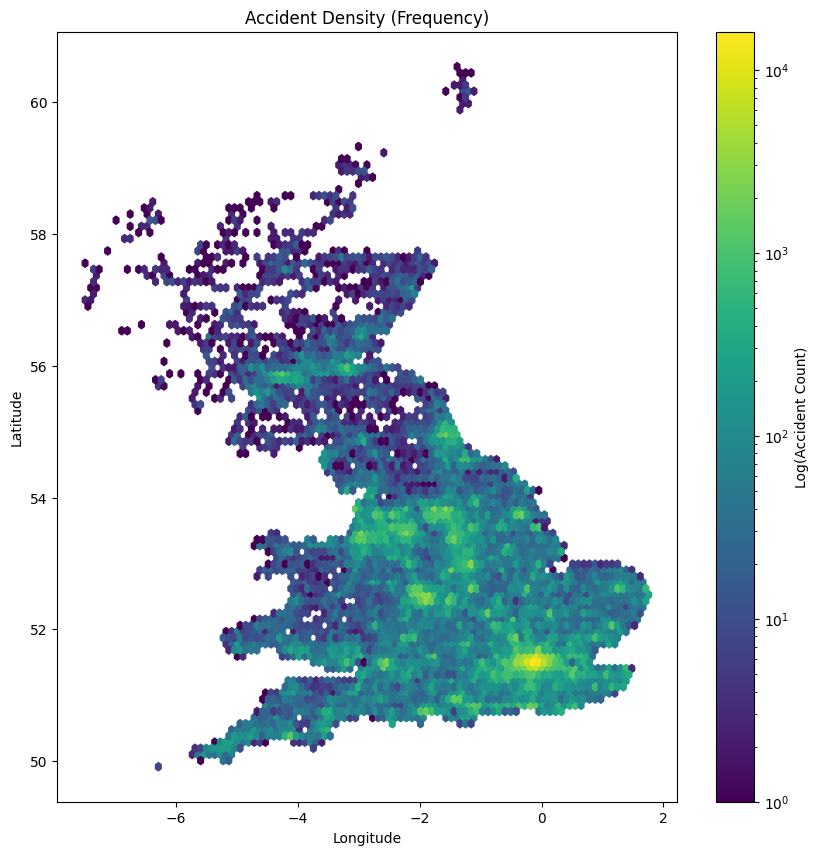

In [ ]:
plt.figure(figsize=(10, 10))

hb = plt.hexbin(
    df_base['longitude'],
    df_base['latitude'],
    gridsize=100,
    bins='log'
)

plt.colorbar(hb, label='Log(Accident Count)')
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Accident Density (Frequency)")

plt.show()

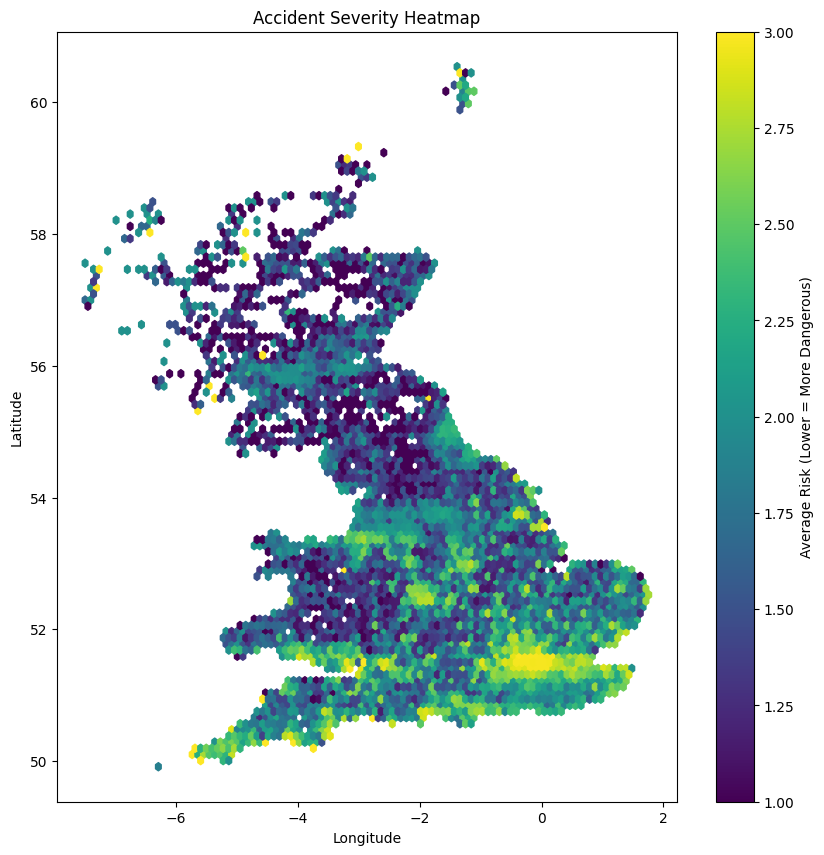

In [ ]:
plt.figure(figsize=(10, 10))

hb = plt.hexbin(
    df_base['longitude'],
    df_base['latitude'],
    C=df_base['predicted_risk'],
    reduce_C_function=np.mean,
    gridsize=100
)

plt.colorbar(hb, label='Average Risk (Lower = More Dangerous)')
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Accident Severity Heatmap")

plt.show()


===== ACCIDENT COUNT BY HOUR =====
hour
0      7772
1      5493
2      3975
3      3339
4      3012
5      4700
6      9537
7     20098
8     31404
9     21945
10    22265
11    25765
12    29250
13    30409
14    32728
15    41185
16    41597
17    43722
18    35556
19    27533
20    20180
21    16638
22    14389
23    10918
Name: count, dtype: int64


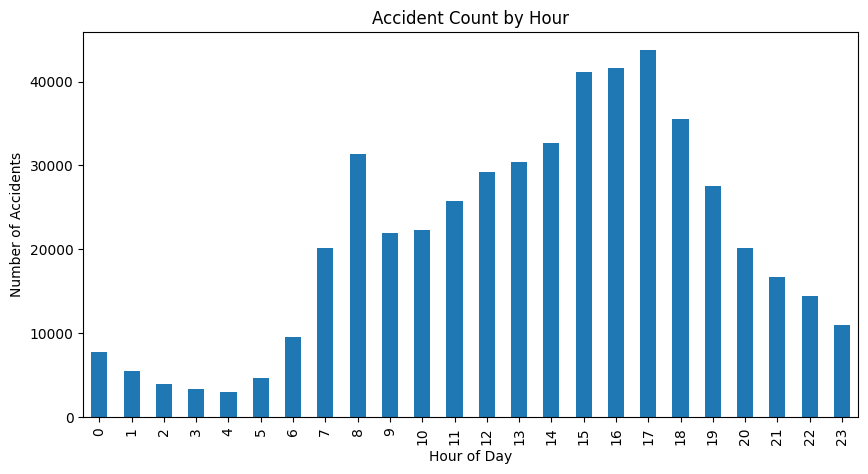

In [ ]:
accidents_by_hour = df_base['hour'].value_counts().sort_index()

print("\n===== ACCIDENT COUNT BY HOUR =====")
print(accidents_by_hour)

plt.figure(figsize=(10,5))
accidents_by_hour.plot(kind='bar')
plt.title("Accident Count by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Accidents")
plt.show()


===== AVERAGE RISK BY HOUR =====
hour
0     2.233273
1     2.174586
2     2.122013
3     2.166217
4     2.219456
5     2.303830
6     2.420468
7     2.511991
8     2.599764
9     2.500889
10    2.451201
11    2.430312
12    2.442291
13    2.460193
14    2.453893
15    2.484958
16    2.450730
17    2.453890
18    2.476207
19    2.441761
20    2.378196
21    2.283207
22    2.221767
23    2.223393
Name: predicted_risk, dtype: float64


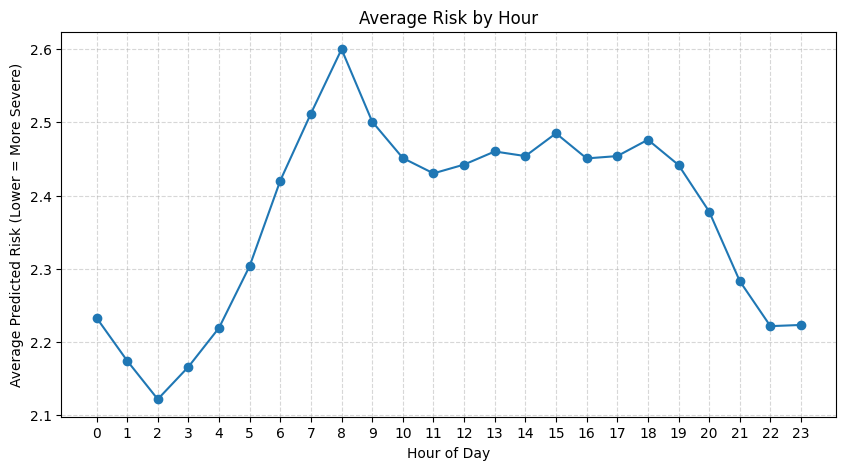

In [ ]:
risk_by_hour = df_base.groupby('hour')['predicted_risk'].mean()

print("\n===== AVERAGE RISK BY HOUR =====")
print(risk_by_hour)

plt.figure(figsize=(10,5))
risk_by_hour.plot(marker='o')
plt.xticks(range(0,24))
plt.grid(True, linestyle='--', alpha=0.5)

plt.title("Average Risk by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Predicted Risk (Lower = More Severe)")
plt.show()

In [ ]:
df_base['is_weekend'] = df_base['day_of_week'].isin([1, 7]).astype(int)
weekend_risk = df_base.groupby('is_weekend')['predicted_risk'].mean()

print("\n===== WEEKEND VS WEEKDAY RISK =====")
print(weekend_risk)


===== WEEKEND VS WEEKDAY RISK =====
is_weekend
0    2.456614
1    2.367184
Name: predicted_risk, dtype: float64


In [ ]:
df_base['is_night'] = df_base['hour'].apply(lambda x: 1 if (x >= 20 or x <= 5) else 0)
night_risk = df_base.groupby('is_night')['predicted_risk'].mean()

print("\n===== NIGHT VS DAY RISK =====")
print(night_risk)


===== NIGHT VS DAY RISK =====
is_night
0    2.471455
1    2.264057
Name: predicted_risk, dtype: float64



===== RISK BY WEATHER CONDITIONS =====
weather_conditions
 7    2.311111
 4    2.358736
 5    2.362431
-1    2.384615
 1    2.404896
 2    2.430763
 3    2.609420
 6    2.667808
 8    2.786037
 9    2.934251
Name: predicted_risk, dtype: float64


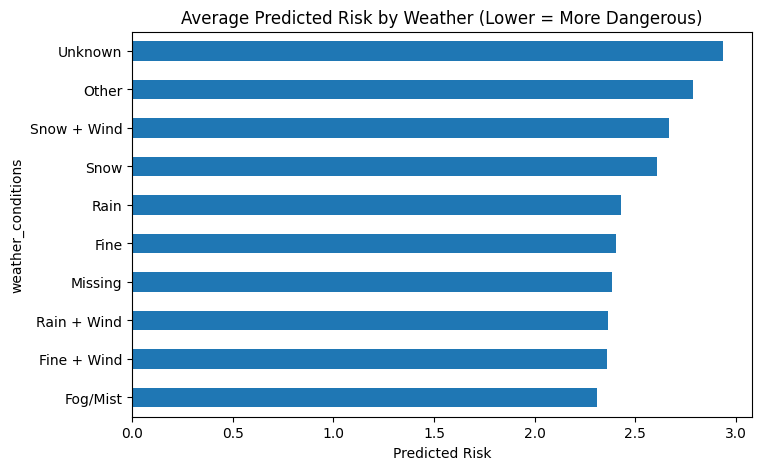

In [ ]:
weather_risk = df_base.groupby('weather_conditions')['predicted_risk'].mean()

print("\n===== RISK BY WEATHER CONDITIONS =====")
print(weather_risk.sort_values())

weather_labels = {
    1: "Fine",
    2: "Rain",
    3: "Snow",
    4: "Fine + Wind",
    5: "Rain + Wind",
    6: "Snow + Wind",
    7: "Fog/Mist",
    8: "Other",
    9: "Unknown",
    -1: "Missing"
}

weather_plot = weather_risk.sort_values()
weather_plot.index = weather_plot.index.map(weather_labels)

plt.figure(figsize=(8,5))
weather_plot.plot(kind='barh')
plt.title("Average Predicted Risk by Weather (Lower = More Dangerous)")
plt.xlabel("Predicted Risk")
plt.show()


===== RISK BY ROAD SURFACE CONDITIONS =====
road_surface_conditions
 2    2.358413
 1    2.441197
 5    2.662607
 3    2.682288
 4    2.711230
-1    2.845075
 9    2.977353
Name: predicted_risk, dtype: float64


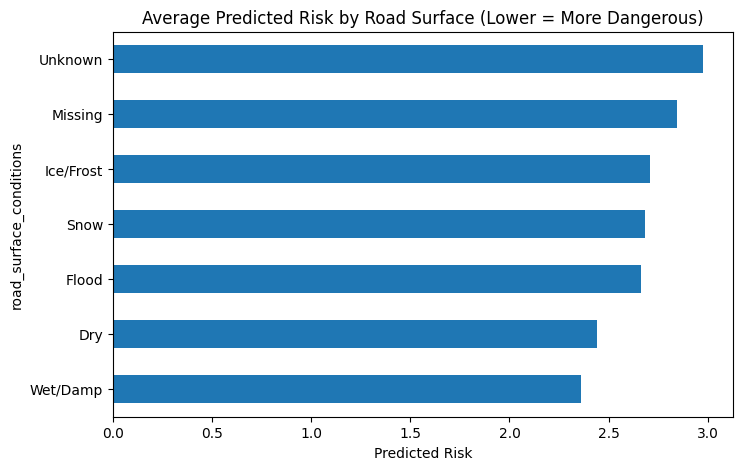

In [ ]:
road_surface_risk = df_base.groupby('road_surface_conditions')['predicted_risk'].mean()

print("\n===== RISK BY ROAD SURFACE CONDITIONS =====")
print(road_surface_risk.sort_values())

road_labels = {
    1: "Dry",
    2: "Wet/Damp",
    3: "Snow",
    4: "Ice/Frost",
    5: "Flood",
    6: "Oil/Diesel",
    7: "Mud",
    9: "Unknown",
    -1: "Missing"
}

road_plot = road_surface_risk.sort_values()
road_plot.index = road_plot.index.map(road_labels)

plt.figure(figsize=(8,5))
road_plot.plot(kind='barh')
plt.title("Average Predicted Risk by Road Surface (Lower = More Dangerous)")
plt.xlabel("Predicted Risk")
plt.show()


===== RISK BY LIGHT CONDITIONS =====
light_conditions
 6    1.670215
-1    2.105263
 5    2.380005
 4    2.453632
 1    2.477884
 7    2.736276
Name: predicted_risk, dtype: float64


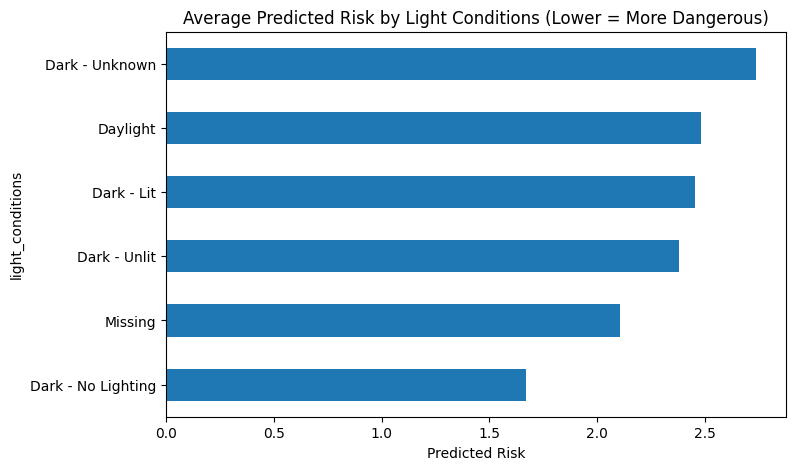

In [ ]:
light_risk = df_base.groupby('light_conditions')['predicted_risk'].mean()

print("\n===== RISK BY LIGHT CONDITIONS =====")
print(light_risk.sort_values())

light_labels = {
    1: "Daylight",
    4: "Dark - Lit",
    5: "Dark - Unlit",
    6: "Dark - No Lighting",
    7: "Dark - Unknown",
    -1: "Missing"
}

light_plot = light_risk.sort_values()
light_plot.index = light_plot.index.map(light_labels)

plt.figure(figsize=(8,5))
light_plot.plot(kind='barh')
plt.title("Average Predicted Risk by Light Conditions (Lower = More Dangerous)")
plt.xlabel("Predicted Risk")
plt.show()


===== TOP FEATURE IMPORTANCE =====
latitude               0.167438
longitude              0.150352
speed_limit            0.145982
hour                   0.101093
urban_or_rural_area    0.085026
day                    0.082159
month                  0.060369
light_conditions       0.056542
road_type              0.048218
day_of_week            0.047473
dtype: float64


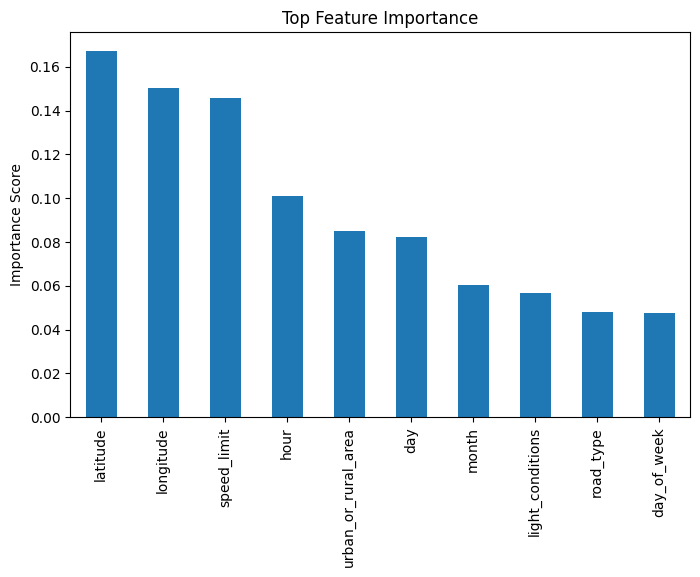

In [ ]:
feature_importance = pd.Series(
    rf_final_full.feature_importances_,
    index=X_full.columns
).sort_values(ascending=False)

print("\n===== TOP FEATURE IMPORTANCE =====")
print(feature_importance.head(10))

plt.figure(figsize=(8,5))
feature_importance.head(10).plot(kind='bar')
plt.title("Top Feature Importance")
plt.ylabel("Importance Score")
plt.show()